# 更好的手动特征工程
虽然featuretools提供了自动特征工程，但是dfs巨慢，这让人头疼。

这促使我寻找更好的自动或者手动方式。


参考Feature Selection with Null Importances
- 有效特征面对假标签表现得应该很差
- 无效特征面对真假标签表现得差不多

我们可以用将标签不断打散，每次lgbm计算特征，就可以识别出无效特征了

以apptrain开始

In [2]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')


In [3]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')

In [4]:
train_labels = application_train['TARGET']
train_ids = application_train['SK_ID_CURR']
test_ids = application_test['SK_ID_CURR']
train_features = application_train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = application_test.drop(columns=['SK_ID_CURR'])

In [11]:
for col in train_features.select_dtypes(include=['object']).columns:
    train_features[col] = train_features[col].astype('category')

In [54]:
def get_features_importance(train_features, train_labels):
    lgbm_model = LGBMClassifier(
        n_estimators=100,      
        learning_rate=0.1, 
        max_depth=8,      
        random_state=42,   
    )
    lgbm_model.fit(train_features, train_labels)
    features_importance = pd.DataFrame(
        {
            'gain': lgbm_model.booster_.feature_importance(importance_type='gain'),
            'split': lgbm_model.booster_.feature_importance(importance_type='split'),
            'feature': lgbm_model.feature_name_
        }
    )
    return features_importance

In [55]:
actual_fi_df = get_features_importance(train_features, train_labels)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11311
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


多次shuffle
- pd没有这个函数， 使用`.sample(frac=1)` 全采样
  - 这个服从正太分布采用

In [56]:
runs = 50
fi_list = []
for i in range(runs):
    shuffle_train_labels = train_labels.sample(frac=1)
    fi_df = get_features_importance(train_features, shuffle_train_labels)
    fi_df['run'] = i + 1
    fi_list.append(fi_df)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11311
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11311
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 116
[LightGBM]

In [57]:
fi_dfs = pd.concat(fi_list, axis=0, ignore_index=True)

In [60]:
fi_dfs[fi_dfs['feature'] == 'NAME_CONTRACT_TYPE']

,gain,split,feature,run
0,13.512700,1,NAME_CONTRACT_TYPE,1
120,28.182740,3,NAME_CONTRACT_TYPE,2
240,67.178120,6,NAME_CONTRACT_TYPE,3
360,37.220660,3,NAME_CONTRACT_TYPE,4
480,16.645969,2,NAME_CONTRACT_TYPE,5
...,...,...,...,...
9000,28.127130,3,NAME_CONTRACT_TYPE,76
9120,38.784301,3,NAME_CONTRACT_TYPE,77
9240,12.401240,2,NAME_CONTRACT_TYPE,78
9360,6.858290,1,NAME_CONTRACT_TYPE,79


我们可以绘制 这些重要性得分布，
- 如果真实重要性与随机重要性相近，那就是假特征

In [105]:
actual_fi_df.sort_values(by='gain')

,gain,split,feature
94,0.000000,0,FLAG_DOCUMENT_2
102,0.000000,0,FLAG_DOCUMENT_10
34,0.000000,0,LIVE_REGION_NOT_WORK_REGION
33,0.000000,0,REG_REGION_NOT_WORK_REGION
32,0.000000,0,REG_REGION_NOT_LIVE_REGION
...,...,...,...
6,4363.998517,136,AMT_CREDIT
38,11747.992508,479,ORGANIZATION_TYPE
39,11884.250595,246,EXT_SOURCE_1
40,33531.526984,175,EXT_SOURCE_2


In [96]:
def plot_importance_distribution_of_feature(actual_fi_df, df, feature_name):
    data = df[df['feature'] == feature_name]
    
    actual_gain = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'gain'].iloc[0]
    actual_split = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'split'].iloc[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    sns.histplot(data['gain'], alpha=0.3, label='Null Gain', ax=ax1, kde=True)
    ax1.axvline(x=actual_gain,  linestyle='--', label=f'Actual: {actual_gain:.1f}')
    ax1.set_title(f'Gain Importance: {feature_name}')
    ax1.legend()
    
    sns.histplot(data['split'],  alpha=0.3, label='Null Split', ax=ax2, kde=True)
    ax2.axvline(x=actual_split,  linestyle='--', label=f'Actual: {actual_split}')
    ax2.set_title(f'Split Importance: {feature_name}')
    ax2.legend()
    
    plt.tight_layout()


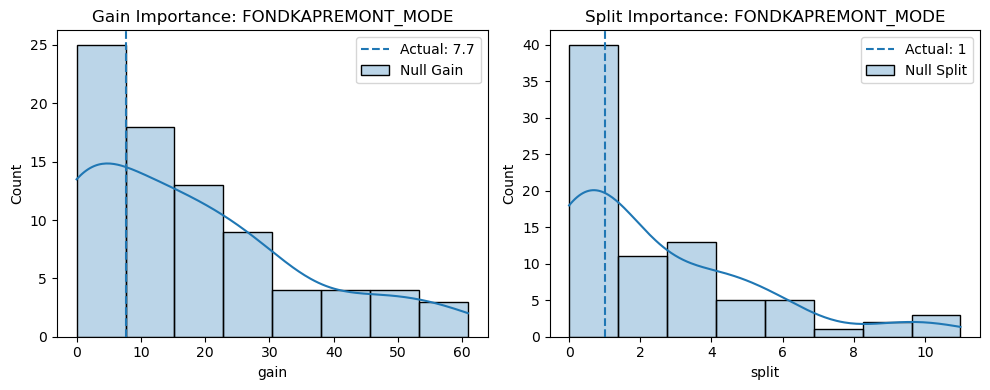

In [104]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'FONDKAPREMONT_MODE')

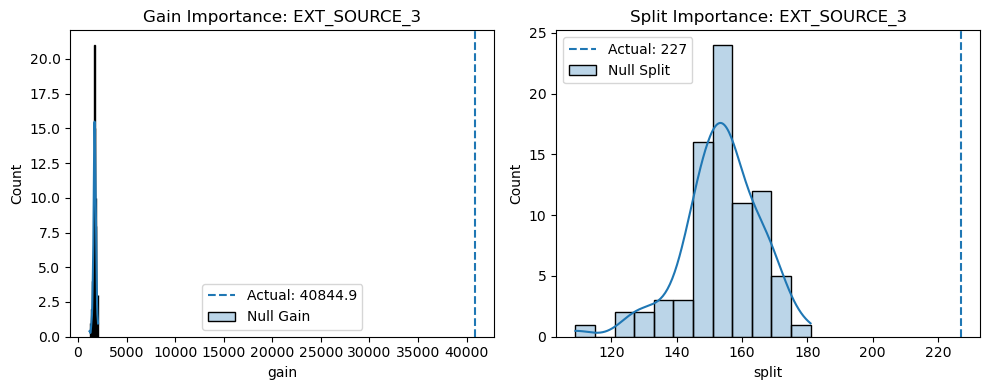

In [106]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'EXT_SOURCE_3')

我们以分布得75分位数 作为 分布值， 去与真实对比。 越接近1越好。为了更方便，使用np.log， 0区分

In [153]:
def get_feature_score(actual_importance, shuffle_importances, feature_name):
    feature_actual_gain = actual_importance[actual_importance['feature'] == feature_name]['gain']
    feature_actual_split = actual_importance[actual_importance['feature'] == feature_name]['split']
    feature_shuffle_gains = shuffle_importances[shuffle_importances['feature'] == feature_name]['gain']
    feature_shuffle_splits = shuffle_importances[shuffle_importances['feature'] == feature_name]['split']
    return pd.DataFrame({
        'feature': feature_name,
        'gain_score':  np.log(1e-10 + feature_actual_gain / np.percentile(feature_shuffle_gains, 75)),
        'split_score': np.log(1e-10 + feature_actual_split / np.percentile(feature_shuffle_splits, 75)),
    })

In [154]:
get_feature_score(actual_fi_df, fi_dfs, 'CODE_GENDER')

,feature,gain_score,split_score
1,CODE_GENDER,3.293217,1.7492


In [155]:
features_score = []
for f in actual_fi_df['feature'].unique():
    features_score.append(get_feature_score(actual_fi_df, fi_dfs, f))

In [157]:
features_score = pd.concat(features_score, ignore_index=True)

In [158]:
plot_gain_features_score = features_score.sort_values(by='gain_score', ascending=False)
plot_split_features_score = features_score.sort_values(by='split_score', ascending=False)


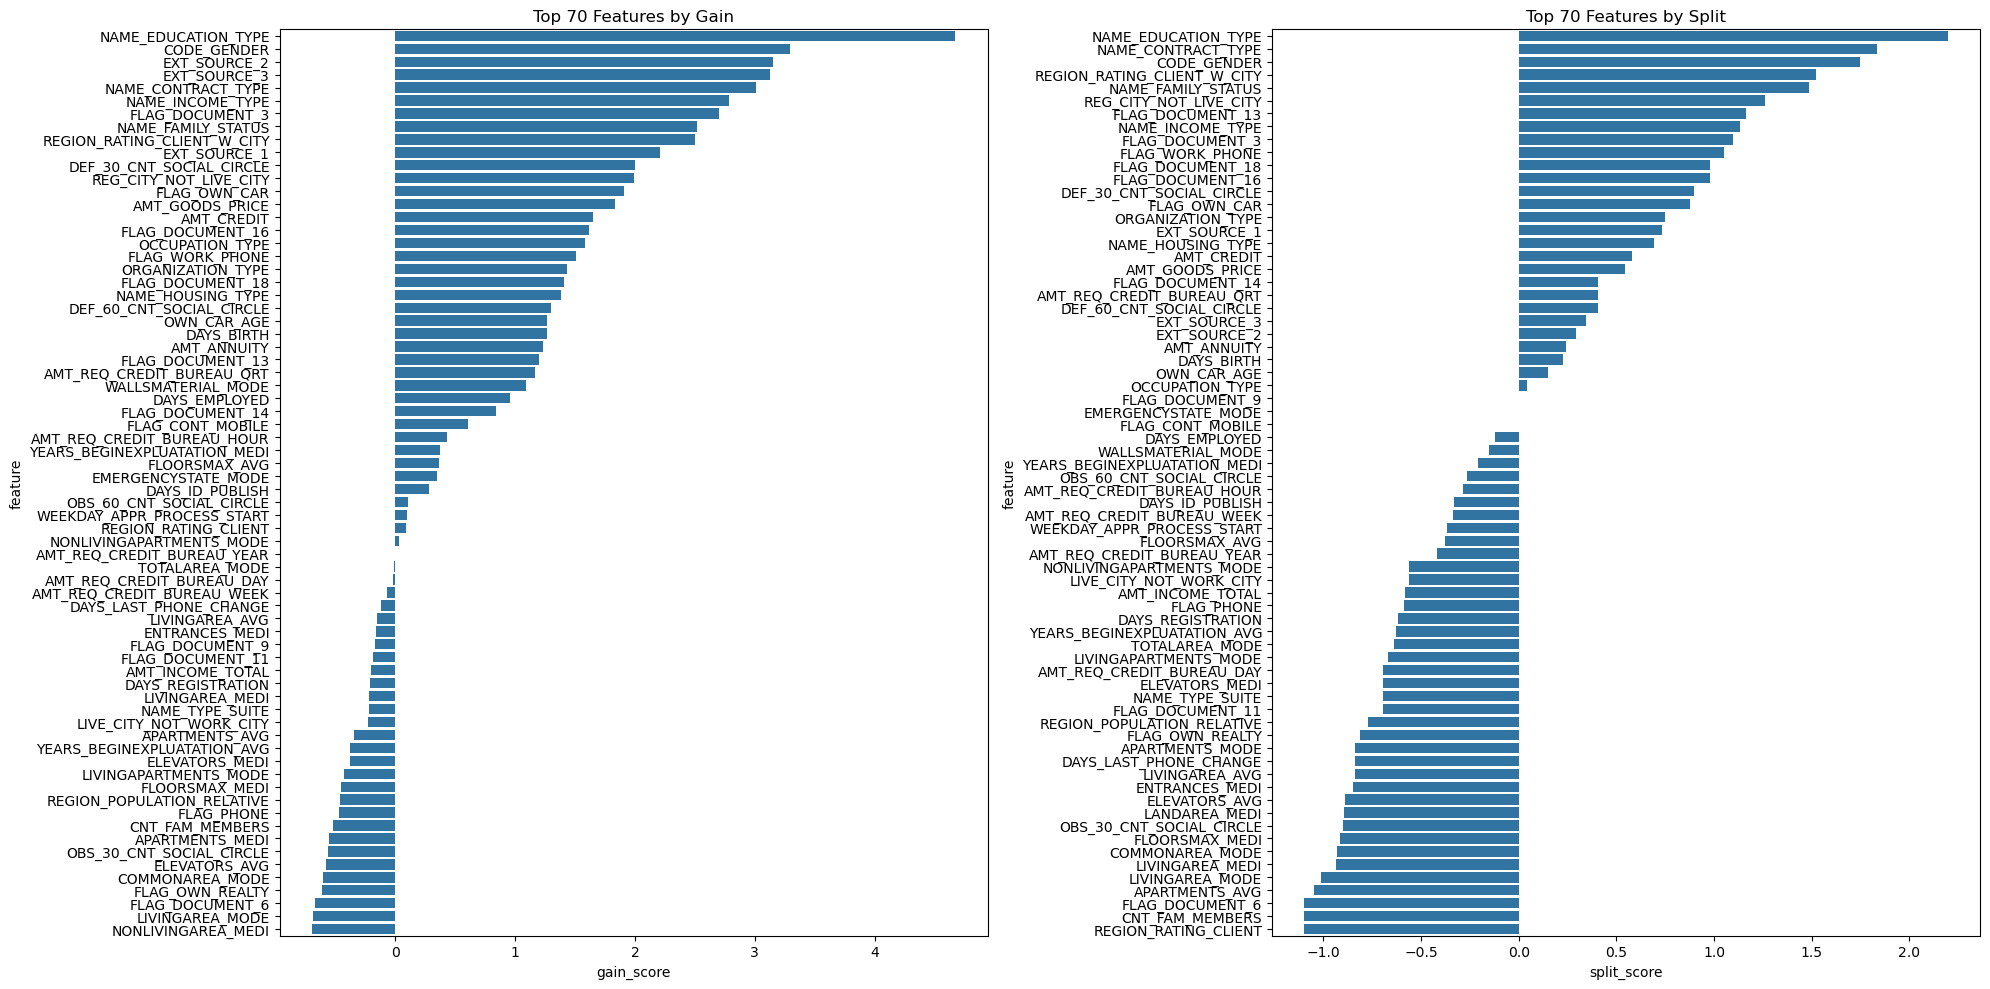

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.barplot(data=plot_gain_features_score.head(70), x='gain_score', y='feature', ax=axes[0])
axes[0].set_title('Top 70 Features by Gain')

sns.barplot(data=plot_split_features_score.head(70), x='split_score', y='feature', ax=axes[1])
axes[1].set_title('Top 70 Features by Split')

plt.tight_layout()